In [1]:
import sqlite3
from collections import defaultdict
import matplotlib.pyplot as plt
import numpy as np

DB = '../data/humans_clean.sqlite3'
conn = sqlite3.connect(DB)
conn.execute('PRAGMA cache_size=-500000')

# Two long civilisational arcs: Chinese dynasties and Greek/Roman world

chinese_chain = [
    ('Han',   "polity_name LIKE 'Han Dynasty%'"),
    ('Sui',   "polity_name LIKE 'Sui Dynasty%'"),
    ('Tang',  "polity_name LIKE 'Tang Dynasty%'"),
    ('Song',  "polity_name LIKE 'Northern Song%' OR polity_name LIKE 'Southern Song%'"),
    ('Yuan',  "polity_name LIKE '%Yuan Dynasty%'"),
    ('Ming',  "polity_name LIKE '%Ming Dynasty%'"),
    ('Qing',  "polity_name LIKE '%Qing Dynasty%'"),
]

greek_roman_chain = [
    ('Greek City-States',  "polity_name = 'Greek City-States'"),
    ('Roman Republic',     "polity_name = '(Roman Republic);Roman Republic'"),
    ('Roman Empire',       "polity_name LIKE 'Roman Empire%'"),
    ('Byzantine',          "polity_name LIKE 'Byzantine Empire' OR polity_name LIKE 'Eastern Roman Empire%'"),
]

def get_chain_data(chain, bin_w=50):
    """For a chain of polities, get scientist and artist counts per time bin."""
    sci_map = defaultdict(int)
    art_map = defaultdict(int)
    tot_map = defaultdict(int)
    polity_spans = []

    for label, where in chain:
        rows = conn.execute(f'''
            SELECT (impact_year / {bin_w}) * {bin_w} as time_bin,
                   SUM(is_scientist), SUM(is_artist), COUNT(*)
            FROM consolidate
            WHERE ({where})
              AND impact_year IS NOT NULL
            GROUP BY time_bin
        ''').fetchall()
        for b, s, a, t in rows:
            sci_map[b] += s
            art_map[b] += a
            tot_map[b] += t

        r = conn.execute(f'''
            SELECT MIN(impact_year), MAX(impact_year)
            FROM consolidate WHERE ({where}) AND impact_year IS NOT NULL
        ''').fetchone()
        if r[0] is not None:
            polity_spans.append((label, r[0], r[1]))

    all_bins = sorted(set(list(sci_map.keys()) + list(art_map.keys())))
    return all_bins, sci_map, art_map, tot_map, polity_spans

chinese_bins, cn_sci, cn_art, cn_tot, cn_spans = get_chain_data(chinese_chain, bin_w=50)
greek_bins, gr_sci, gr_art, gr_tot, gr_spans = get_chain_data(greek_roman_chain, bin_w=50)

conn.close()

print('Chinese world spans:')
for s in cn_spans:
    print(f'  {s[0]:20s} {s[1]}–{s[2]}')
print(f'  Bins: {chinese_bins[0]} to {chinese_bins[-1]}, {len(chinese_bins)} bins')

print('\nGreek/Roman world spans:')
for s in gr_spans:
    print(f'  {s[0]:20s} {s[1]}–{s[2]}')
print(f'  Bins: {greek_bins[0]} to {greek_bins[-1]}, {len(greek_bins)} bins')

Chinese world spans:
  Han                  -201–223
  Sui                  587–622
  Tang                 623–910
  Song                 961–1278
  Yuan                 1294–1374
  Ming                 1375–1644
  Qing                 1645–1911
  Bins: -200 to 1900, 37 bins

Greek/Roman world spans:
  Greek City-States    -800–-65
  Roman Republic       -465–-32
  Roman Empire         -30–394
  Byzantine            395–1473
  Bins: -800 to 1450, 46 bins


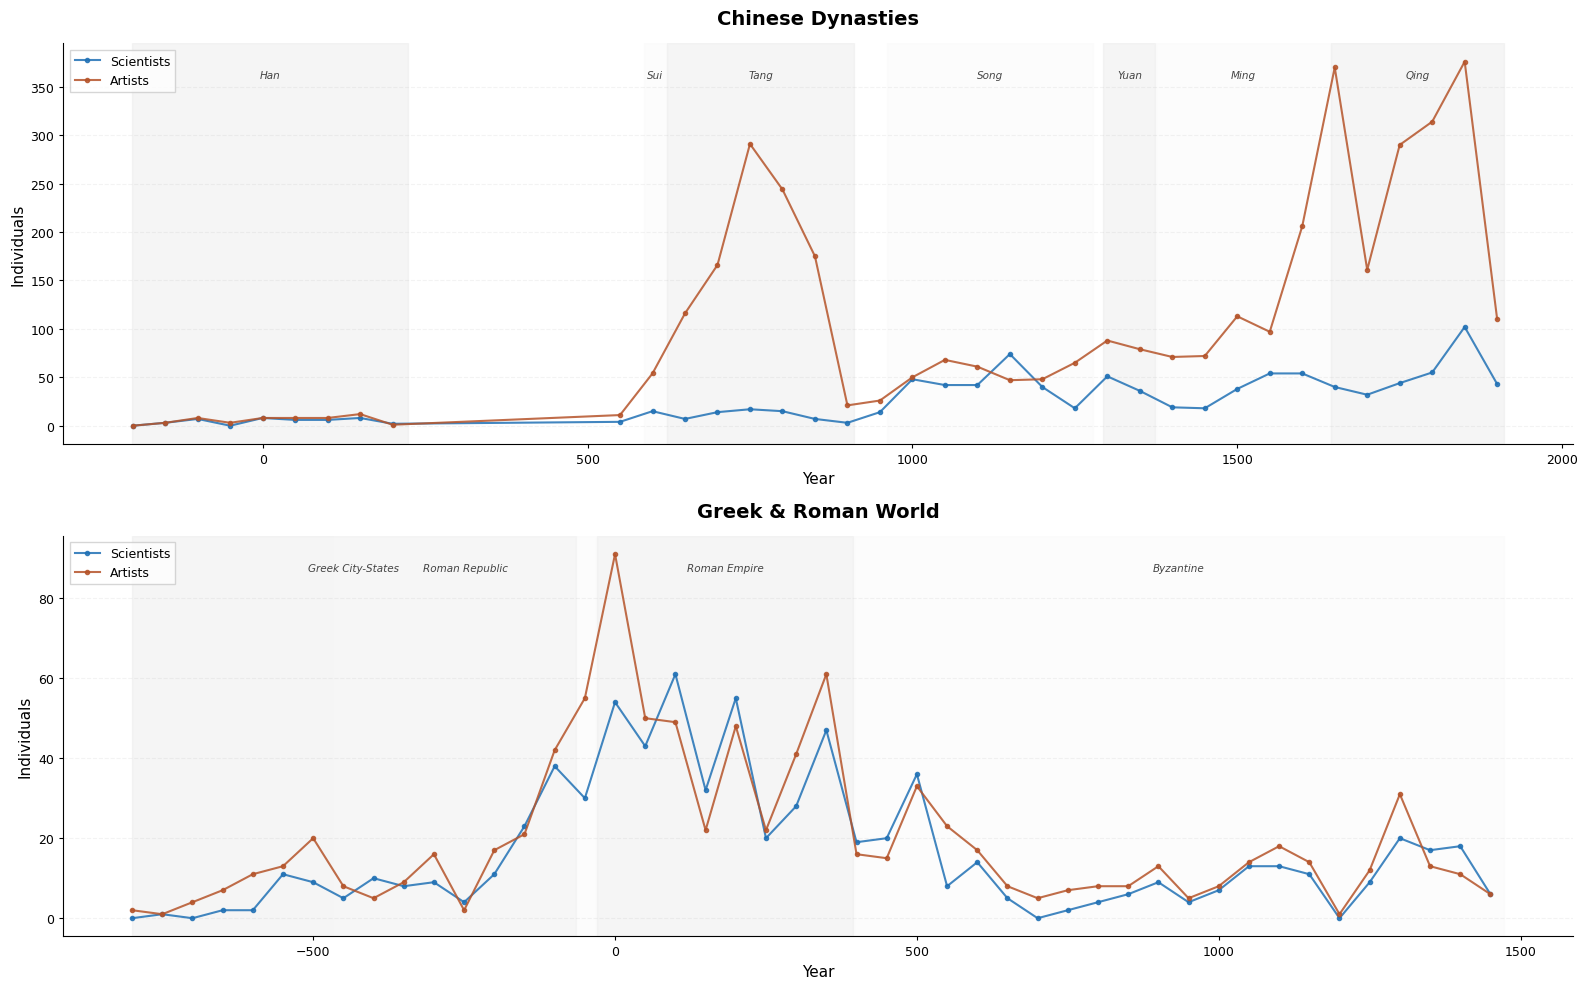

In [2]:
def plot_chain(ax, bins, sci_map, art_map, tot_map, spans, title):
    sci_vals = [sci_map.get(b, 0) for b in bins]
    art_vals = [art_map.get(b, 0) for b in bins]

    ax.plot(bins, sci_vals, '-o', color='#2171b5', label='Scientists',
            linewidth=1.5, markersize=3, alpha=0.85)
    ax.plot(bins, art_vals, '-o', color='#b5542a', label='Artists',
            linewidth=1.5, markersize=3, alpha=0.85)

    # Shade polity spans with alternating light backgrounds
    colors_bg = ['#e8e8e8', '#f8f8f8']
    for i, (label, yr_s, yr_e) in enumerate(spans):
        ax.axvspan(yr_s, yr_e, alpha=0.4, color=colors_bg[i % 2], zorder=0)

    ax.set_title(title, fontsize=14, fontweight='bold', color='black',
                 loc='center', pad=14)
    ax.set_xlabel('Year', fontsize=11)
    ax.set_ylabel('Individuals', fontsize=11)
    ax.legend(fontsize=9, loc='upper left', frameon=True, fancybox=False,
              edgecolor='#cccccc')
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.tick_params(axis='both', which='both', length=3, labelsize=9)
    ax.grid(axis='y', alpha=0.15, linestyle='--')

    # Place polity labels at top after y-axis is set
    ymax = ax.get_ylim()[1]
    for i, (label, yr_s, yr_e) in enumerate(spans):
        mid = (yr_s + yr_e) / 2
        ax.text(mid, ymax * 0.93, label, ha='center', va='top',
                fontsize=7.5, color='#444444', style='italic')


fig, axes = plt.subplots(2, 1, figsize=(16, 10))

plot_chain(axes[0], chinese_bins, cn_sci, cn_art, cn_tot, cn_spans,
           'Chinese Dynasties')
plot_chain(axes[1], greek_bins, gr_sci, gr_art, gr_tot, gr_spans,
           'Greek & Roman World')

plt.tight_layout()
plt.show()